# Saddle Point Navigation with Newton Method

### With no angle rotation

Saved estimates to gradient_hessian_estimates.txt


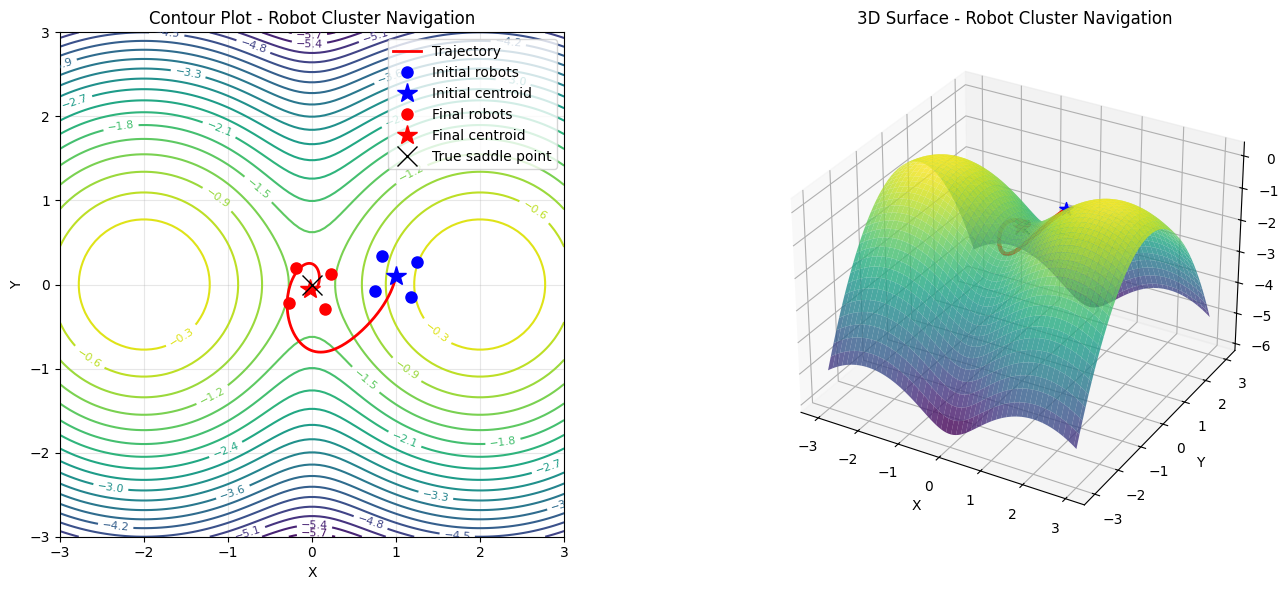

Initial centroid: [1.  0.1]
Final centroid: [-0.02270505 -0.04815997]
Distance to true saddle point: 0.0532


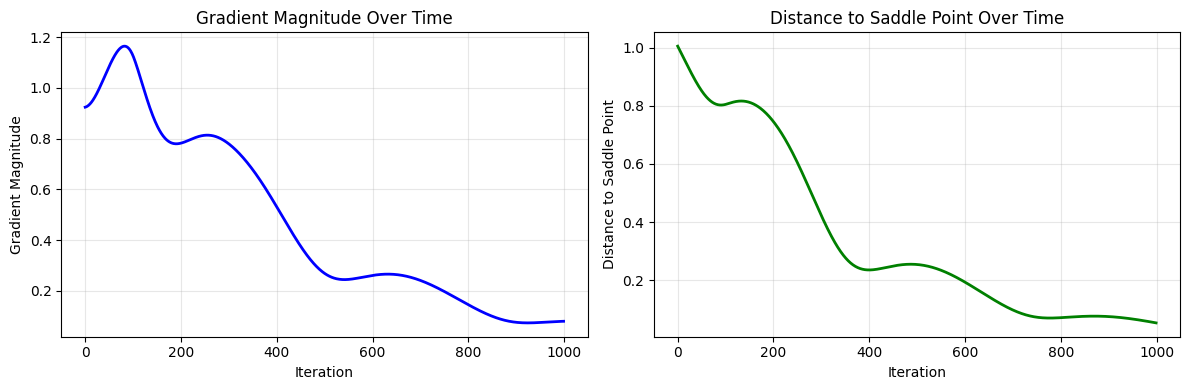

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations

class SaddlePointNavigator:
    def __init__(self, robot_distance=0.3, step_size=0.01, n_iterations=100):
        self.robot_distance = robot_distance
        self.step_size = step_size
        self.n_iterations = n_iterations
        self.history = {
            'centroids': [],
            'gradients': [],
            'hessians': []
        }
        
    def scalar_field(self, x, y):
        """Create smooth bimodal scalar field z = log(exp(G1) + exp(G2))"""
        # Two Gaussians with std=1, centered at (-1,0) and (+1,0)
        gaussian1 = -((x + 2)**2 + y**2) / 2  # Exponent of first Gaussian
        gaussian2 = -((x - 2)**2 + y**2) / 2  # Exponent of second Gaussian


        
        # Use log-sum-exp for numerical stability
        max_exp = np.maximum(gaussian1, gaussian2)
        return max_exp + np.log(np.exp(gaussian1 - max_exp) + np.exp(gaussian2 - max_exp))
    
    def initialize_robots(self, centroid, rotation_angle=None):
        """Initialize 4 robots in a square pattern around centroid"""
        if rotation_angle is None:
            #np.random.seed(40)
            rotation_angle = np.random.uniform(0, 2*np.pi)
        
        # Store rotation angle for consistency
        if not hasattr(self, 'rotation_angle'):
            self.rotation_angle = rotation_angle
        else:
            rotation_angle = self.rotation_angle
        
        # Create square pattern
        angles = np.array([0, np.pi/2, np.pi, 3*np.pi/2]) + rotation_angle
        robots = []
        for angle in angles:
            x = centroid[0] + self.robot_distance * np.cos(angle)
            y = centroid[1] + self.robot_distance * np.sin(angle)
            robots.append([x, y])
        
        return np.array(robots)
    
    def estimate_gradient_from_plane(self, points):
        """Estimate gradient from 3 points by fitting a plane"""
        # points is 3x3 array [x, y, z]
        A = np.column_stack([points[:, 0], points[:, 1], np.ones(3)])
        b = points[:, 2]
        
        # Solve for plane coefficients: z = ax + by + c
        coeffs = np.linalg.lstsq(A, b, rcond=None)[0]
        
        # Gradient is [dz/dx, dz/dy] = [a, b]
        return coeffs[0], coeffs[1]
    
    def estimate_hessian_corrected(self, centroids, gradients):
        """Estimate Hessian using corrected approach: fit planes to gradient components"""
        # We have 4 centroids and 4 gradients [dz/dx, dz/dy]
        # Fit plane to dz/dx values: dz/dx = a*x + b*y + c
        # This gives us d²z/dx² = a, d²z/dxdy = b
        
        # Extract gradient components
        dz_dx = gradients[:, 0]  # 4 values of dz/dx
        dz_dy = gradients[:, 1]  # 4 values of dz/dy
        
        # Setup system for dz/dx: dz/dx = a*x + b*y + c
        A = np.column_stack([centroids[:, 0], centroids[:, 1], np.ones(4)])
        
        # Solve for dz/dx plane coefficients
        try:
            coeffs_dx = np.linalg.lstsq(A, dz_dx, rcond=None)[0]
            d2z_dx2 = coeffs_dx[0]      # d²z/dx²
            d2z_dxdy_from_dx = coeffs_dx[1]  # d²z/dxdy from dz/dx fit
        except np.linalg.LinAlgError:
            d2z_dx2 = 0
            d2z_dxdy_from_dx = 0
        
        # Solve for dz/dy plane coefficients  
        try:
            coeffs_dy = np.linalg.lstsq(A, dz_dy, rcond=None)[0]
            d2z_dxdy_from_dy = coeffs_dy[0]  # d²z/dxdy from dz/dy fit
            d2z_dy2 = coeffs_dy[1]      # d²z/dy²
        except np.linalg.LinAlgError:
            d2z_dxdy_from_dy = 0
            d2z_dy2 = 0
        
        # Average the mixed partial derivatives for symmetry
        d2z_dxdy = (d2z_dxdy_from_dx + d2z_dxdy_from_dy) / 2
        
        # Construct Hessian matrix
        H = np.array([[d2z_dx2, d2z_dxdy],
                      [d2z_dxdy, d2z_dy2]])
        
        
        H = np.array([[d2z_dx2, d2z_dxdy_from_dx],
                      [d2z_dxdy_from_dy, d2z_dy2]])
        
        
        return H
    
    def saddle_point_step_eigenvalue(self, gradient, hessian):
        """Compute step direction for saddle point using eigenvalue approach"""
        # Compute eigenvalues and eigenvectors
        try:
            eigenvalues, eigenvectors = np.linalg.eigh(hessian)
        except np.linalg.LinAlgError:
            # If Hessian is singular, use gradient descent
            if np.linalg.norm(gradient) > 0:
                return -gradient / np.linalg.norm(gradient)
            else:
                return np.array([0.0, 0.0])
        
        # For saddle point navigation, we want to move towards where gradient = 0
        # Use Newton's method: step = -H^(-1) * gradient
        try:
            # Check if Hessian is invertible
            det = np.linalg.det(hessian)
            if abs(det) > 1e-10:
                step = -np.linalg.solve(hessian, gradient)
            else:
                # Hessian is singular, use pseudoinverse
                step = -np.linalg.pinv(hessian) @ gradient
        except np.linalg.LinAlgError:
            # Fallback to gradient descent
            if np.linalg.norm(gradient) > 0:
                step = -gradient / np.linalg.norm(gradient)
            else:
                step = np.array([0.0, 0.0])
        
        # Limit step size for stability
        max_step = 1.0
        if np.linalg.norm(step) > max_step:
            step = step / np.linalg.norm(step) * max_step
            
        return step
    
    def navigate(self, start_centroid):
        """Main navigation loop"""
        centroid = np.array(start_centroid, dtype=float)
        
        # Store initial position
        self.initial_centroid = centroid.copy()
        self.initial_robots = self.initialize_robots(centroid)
        
        for iteration in range(self.n_iterations):
            # Initialize robots around current centroid
            robots = self.initialize_robots(centroid)
            
            # Get measurements
            z_values = np.array([self.scalar_field(r[0], r[1]) for r in robots])
            
            # Create 3D points for gradient estimation
            points_3d = np.column_stack([robots, z_values])
            
            # Estimate gradients using 4 choose 3
            gradients = []
            centroids = []
            
            for combo in combinations(range(4), 3):
                selected_points = points_3d[list(combo)]
                gradient = self.estimate_gradient_from_plane(selected_points)
                gradients.append(gradient)
                
                # Centroid of the 3 selected robots
                centroid_3 = np.mean(robots[list(combo)], axis=0)
                centroids.append(centroid_3)
            
            gradients = np.array(gradients)
            centroids = np.array(centroids)
            
            # Estimate Hessian using corrected approach
            hessian = self.estimate_hessian_corrected(centroids, gradients)
            
            # Average gradient as estimate at main centroid
            avg_gradient = np.mean(gradients, axis=0)
            
            # Store history
            self.history['centroids'].append(centroid.copy())
            self.history['gradients'].append(avg_gradient.copy())
            self.history['hessians'].append(hessian.copy())
            
            # Compute step direction using eigenvalue approach
            direction = self.saddle_point_step_eigenvalue(avg_gradient, hessian)
            
            # Update centroid position
            centroid = centroid + self.step_size * direction
            
        # Store final position
        self.final_centroid = centroid
        self.final_robots = self.initialize_robots(centroid)
        
        return centroid
    
    def save_estimates(self, filename='gradient_hessian_estimates.txt'):
        """Save gradient and Hessian estimates to file"""
        try:
            with open(filename, 'w') as f:
                f.write("GRADIENT AND HESSIAN ESTIMATES\n")
                f.write("="*50 + "\n\n")
                
                for i in range(len(self.history['gradients'])):
                    eigenvals, _ = np.linalg.eigh(self.history['hessians'][i])
                    f.write(f"Iteration {i+1}:\n")
                    f.write(f"  Centroid: [{self.history['centroids'][i][0]:.6f}, {self.history['centroids'][i][1]:.6f}]\n")
                    f.write(f"  Gradient: [{self.history['gradients'][i][0]:.6f}, {self.history['gradients'][i][1]:.6f}]\n")
                    f.write(f"  Gradient magnitude: {np.linalg.norm(self.history['gradients'][i]):.6f}\n")
                    f.write(f"  Hessian eigenvalues: [{eigenvals[0]:.6f}, {eigenvals[1]:.6f}]\n")
                    f.write(f"  Hessian:\n")
                    f.write(f"    [[{self.history['hessians'][i][0,0]:.6f}, {self.history['hessians'][i][0,1]:.6f}]\n")
                    f.write(f"     [{self.history['hessians'][i][1,0]:.6f}, {self.history['hessians'][i][1,1]:.6f}]]\n")
                    f.write("\n")
                
                f.write("="*50 + "\n")
                f.write(f"Total iterations: {len(self.history['gradients'])}\n")
                f.write(f"Final centroid: [{self.final_centroid[0]:.6f}, {self.final_centroid[1]:.6f}]\n")
                f.write(f"Distance to saddle point: {np.linalg.norm(self.final_centroid):.6f}\n")
                final_eigenvals, _ = np.linalg.eigh(self.history['hessians'][-1])
                f.write(f"Final Hessian eigenvalues: [{final_eigenvals[0]:.6f}, {final_eigenvals[1]:.6f}]\n")
            
            print(f"Saved estimates to {filename}")
            
        except OSError as e:
            print(f"Could not save to file: {e}")
            print("\nPrinting estimates to console instead:\n")
            print("GRADIENT AND HESSIAN ESTIMATES")
            print("="*50)
            for i in range(min(5, len(self.history['gradients']))):
                eigenvals, _ = np.linalg.eigh(self.history['hessians'][i])
                print(f"\nIteration {i+1}:")
                print(f"  Centroid: {self.history['centroids'][i]}")
                print(f"  Gradient: {self.history['gradients'][i]}")
                print(f"  Gradient magnitude: {np.linalg.norm(self.history['gradients'][i]):.6f}")
                print(f"  Hessian eigenvalues: {eigenvals}")
                print(f"  Hessian:\n{self.history['hessians'][i]}")
            if len(self.history['gradients']) > 5:
                print(f"\n... ({len(self.history['gradients'])-5} more iterations) ...")
            print(f"\nFinal centroid: {self.final_centroid}")
            print(f"Distance to saddle point: {np.linalg.norm(self.final_centroid):.6f}")
    
    def visualize(self):
        """Create visualization of the navigation"""
        fig = plt.figure(figsize=(15, 6))
        
        # Create grid for plotting
        x = np.linspace(-3, 3, 100)
        y = np.linspace(-3, 3, 100)
        X, Y = np.meshgrid(x, y)
        Z = self.scalar_field(X, Y)
        
        # Subplot 1: Contour plot
        ax1 = fig.add_subplot(121)
        contour = ax1.contour(X, Y, Z, levels=20, cmap='viridis')
        ax1.clabel(contour, inline=True, fontsize=8)
        
        # Plot trajectory
        trajectory = np.array(self.history['centroids'])
        ax1.plot(trajectory[:, 0], trajectory[:, 1], 'r-', linewidth=2, label='Trajectory')
        
        # Plot initial robots
        for i, robot in enumerate(self.initial_robots):
            ax1.plot(robot[0], robot[1], 'bo', markersize=8, 
                    label='Initial robots' if i == 0 else '')
        ax1.plot(self.initial_centroid[0], self.initial_centroid[1], 'b*', 
                markersize=15, label='Initial centroid')
        
        # Plot final robots
        for i, robot in enumerate(self.final_robots):
            ax1.plot(robot[0], robot[1], 'ro', markersize=8,
                    label='Final robots' if i == 0 else '')
        ax1.plot(self.final_centroid[0], self.final_centroid[1], 'r*', 
                markersize=15, label='Final centroid')
        
        # Mark saddle point
        ax1.plot(0, 0, 'kx', markersize=15, linewidth=3, label='True saddle point')
        
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.set_title('Contour Plot - Robot Cluster Navigation')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_aspect('equal')
        
        # Subplot 2: 3D surface
        ax2 = fig.add_subplot(122, projection='3d')
        surf = ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
        
        # Plot trajectory in 3D
        z_trajectory = np.array([self.scalar_field(c[0], c[1]) for c in trajectory])
        ax2.plot(trajectory[:, 0], trajectory[:, 1], z_trajectory, 'r-', linewidth=3)
        
        # Plot initial and final positions
        z_initial = self.scalar_field(self.initial_centroid[0], self.initial_centroid[1])
        z_final = self.scalar_field(self.final_centroid[0], self.final_centroid[1])
        
        ax2.scatter(self.initial_centroid[0], self.initial_centroid[1], z_initial, 
                   color='blue', s=100, marker='*')
        ax2.scatter(self.final_centroid[0], self.final_centroid[1], z_final, 
                   color='red', s=100, marker='*')
        ax2.scatter(0, 0, self.scalar_field(0, 0), color='black', s=100, marker='x')
        
        ax2.set_xlabel('X')
        ax2.set_ylabel('Y')
        ax2.set_zlabel('Z')
        ax2.set_title('3D Surface - Robot Cluster Navigation')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print(f"Initial centroid: {self.initial_centroid}")
        print(f"Final centroid: {self.final_centroid}")
        print(f"Distance to true saddle point: {np.linalg.norm(self.final_centroid):.4f}")
        
        # Plot gradient magnitude over time
        fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Gradient magnitude
        grad_mags = [np.linalg.norm(g) for g in self.history['gradients']]
        ax3.plot(grad_mags, 'b-', linewidth=2)
        ax3.set_xlabel('Iteration')
        ax3.set_ylabel('Gradient Magnitude')
        ax3.set_title('Gradient Magnitude Over Time')
        ax3.grid(True, alpha=0.3)
        
        # Distance to origin
        distances = [np.linalg.norm(c) for c in self.history['centroids']]
        ax4.plot(distances, 'g-', linewidth=2)
        ax4.set_xlabel('Iteration')
        ax4.set_ylabel('Distance to Saddle Point')
        ax4.set_title('Distance to Saddle Point Over Time')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()


# Main execution
if __name__ == "__main__":
    # Create navigator
    navigator = SaddlePointNavigator(
        robot_distance=0.3,
        step_size=0.01,
        n_iterations=1000
    )
    
    # Start from a point away from the saddle
    start_centroid = [1.0, 0.1]  # Starting away from saddle point
    
    # Navigate to saddle point
    final_position = navigator.navigate(start_centroid)
    
    # Save estimates
    navigator.save_estimates('gradient_hessian_estimates.txt')
    
    # Visualize results
    navigator.visualize()

## With Angle Optimization

Saved estimates to gradient_hessian_estimates_with_rotation.txt


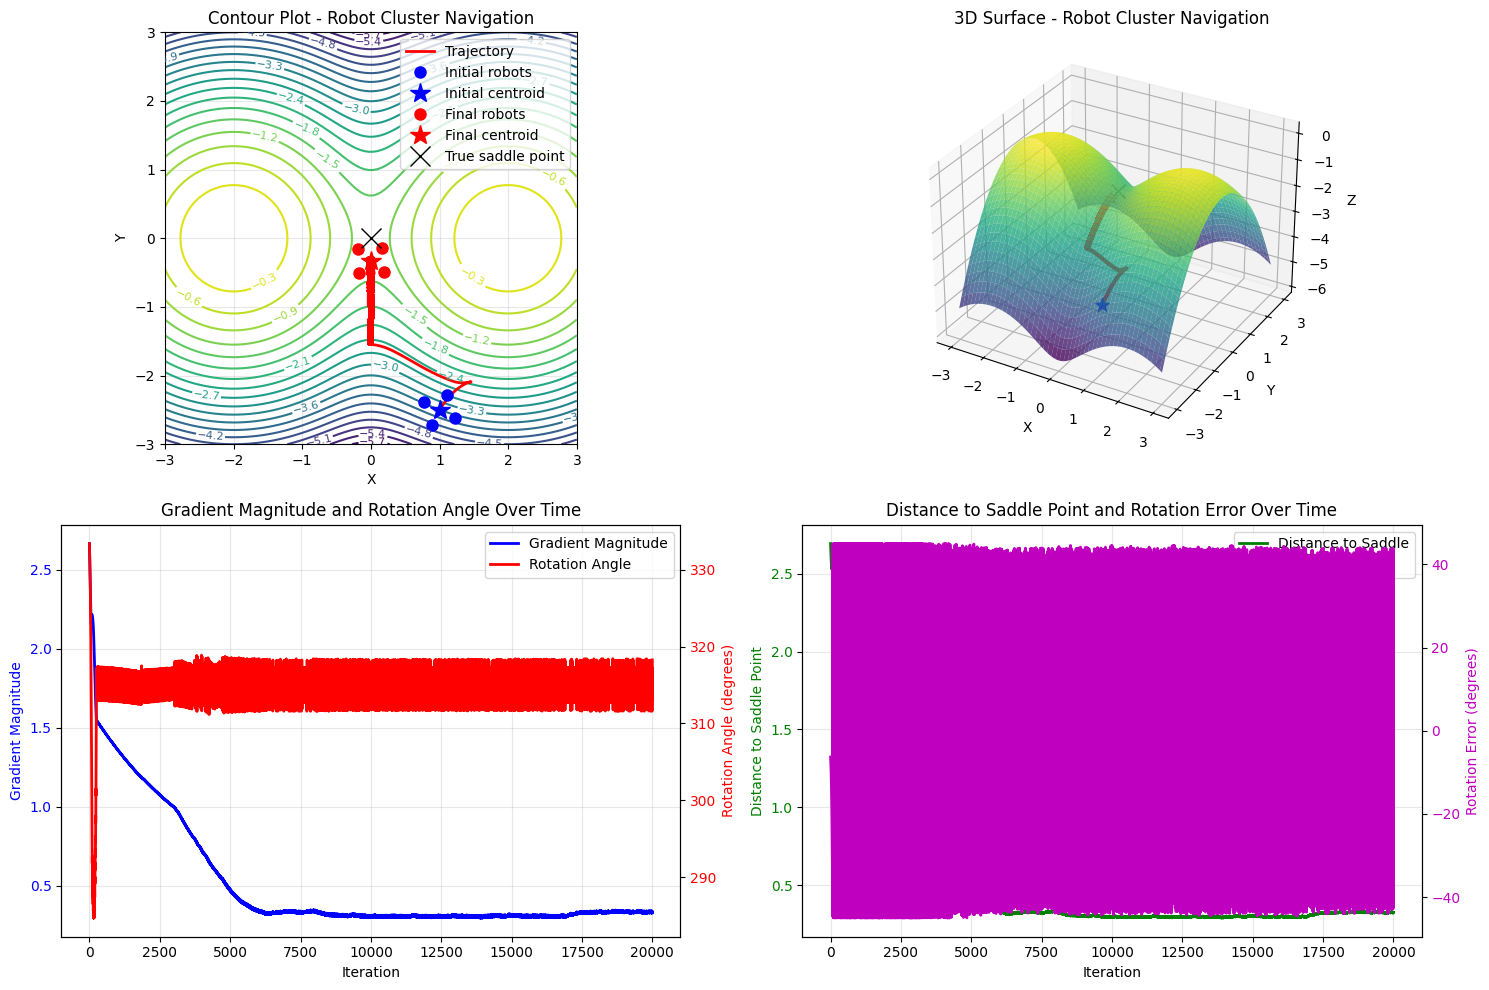


Navigation Summary:
Initial centroid: [ 1.  -2.5]
Final centroid: [-0.00078605 -0.32632782]
Distance to true saddle point: 0.3263
Initial rotation: 333.51°
Final rotation: 318.26°
Total rotation change: -15.25°

Rotation Control Diagnostics:
Max rotation change per step: 0.90°
Average rotation error: 38.11°
Final gradient magnitude: 0.327064


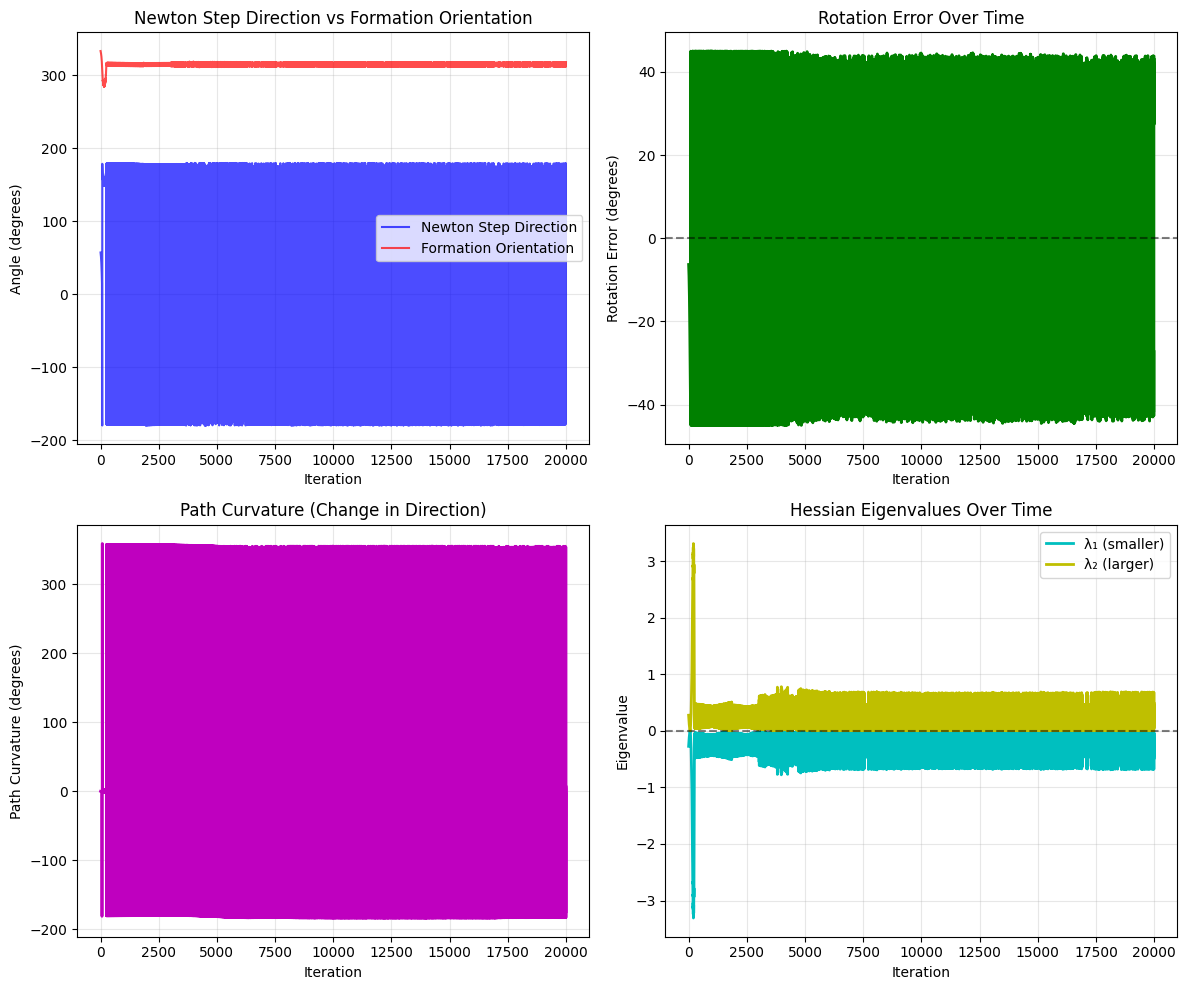

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations

class SaddlePointNavigator:
    def __init__(self, robot_distance=0.3, step_size=0.01, n_iterations=100, rotation_gain=0.3):
        self.robot_distance = robot_distance
        self.step_size = step_size
        self.n_iterations = n_iterations
        self.rotation_gain = rotation_gain  # Proportional gain for rotation control
        self.history = {
            'centroids': [],
            'gradients': [],
            'hessians': [],
            'rotations': [],  # Track rotation angles
            'rotation_errors': []  # Track alignment errors
        }
        
    def scalar_field(self, x, y):
        """Create smooth bimodal scalar field z = log(exp(G1) + exp(G2))"""
        # Two Gaussians with std=1, centered at (-1,0) and (+1,0)
        gaussian1 = -((x + 2)**2 + y**2) / 2  # Exponent of first Gaussian
        gaussian2 = -((x - 2)**2 + y**2) / 2  # Exponent of second Gaussian
        
        # Use log-sum-exp for numerical stability
        max_exp = np.maximum(gaussian1, gaussian2)
        return max_exp + np.log(np.exp(gaussian1 - max_exp) + np.exp(gaussian2 - max_exp))
    
    def initialize_robots(self, centroid, rotation_angle=None):
        """Initialize 4 robots in a square pattern around centroid"""
        if rotation_angle is None:
            rotation_angle = np.random.uniform(0, 2*np.pi)
        
        # Create square pattern with given rotation
        angles = np.array([0, np.pi/2, np.pi, 3*np.pi/2]) + rotation_angle
        robots = []
        for angle in angles:
            x = centroid[0] + self.robot_distance * np.cos(angle)
            y = centroid[1] + self.robot_distance * np.sin(angle)
            robots.append([x, y])
        
        return np.array(robots), rotation_angle
    
    def compute_desired_rotation(self, hessian, current_rotation, gradient):
        """
        Compute desired rotation to align formation with Newton step direction
        Returns the error angle that should be corrected
        """
        try:
            # Compute Newton step direction
            det = np.linalg.det(hessian)
            if abs(det) > 1e-10:
                newton_step = -np.linalg.solve(hessian, gradient)
            else:
                # Use pseudoinverse for singular case
                newton_step = -np.linalg.pinv(hessian) @ gradient
            
            # Normalize the Newton step
            if np.linalg.norm(newton_step) > 1e-10:
                newton_direction = newton_step / np.linalg.norm(newton_step)
                
                # Calculate angle of Newton step direction
                newton_angle = np.arctan2(newton_direction[1], newton_direction[0])
                
                # We want to align one of the robot axes with the Newton direction
                # Since we have a square formation, we can align with 0°, 90°, 180°, or 270°
                # relative to the Newton direction
                
                # Current formation has robots at angles:
                # current_rotation, current_rotation + π/2, current_rotation + π, current_rotation + 3π/2
                
                # We want one of these to point along newton_angle
                # So newton_angle should equal current_rotation + k*π/2 for some k in {0,1,2,3}
                
                # Find the best k
                best_k = None
                min_error = float('inf')
                
                for k in range(4):
                    target_rotation = newton_angle - k * np.pi/2
                    error = target_rotation - current_rotation
                    # Normalize to [-π, π]
                    error = np.arctan2(np.sin(error), np.cos(error))
                    
                    if abs(error) < min_error:
                        min_error = abs(error)
                        best_k = k
                        best_error = error
                
                return best_error
            else:
                # If Newton step is too small, try to align with eigenvectors instead
                eigenvalues, eigenvectors = np.linalg.eigh(hessian)
                
                # Get the eigenvector corresponding to the larger magnitude eigenvalue
                primary_idx = np.argmax(np.abs(eigenvalues))
                principal_direction = eigenvectors[:, primary_idx]
                
                # Calculate angle of principal direction
                principal_angle = np.arctan2(principal_direction[1], principal_direction[0])
                
                # Find closest alignment
                angle_errors = []
                for k in range(4):
                    target_angle = principal_angle + k * np.pi/2
                    error = target_angle - current_rotation
                    error = np.arctan2(np.sin(error), np.cos(error))
                    angle_errors.append(error)
                
                min_idx = np.argmin(np.abs(angle_errors))
                return angle_errors[min_idx]
                
        except np.linalg.LinAlgError:
            # If linear algebra fails, no rotation
            return 0.0
    
    def estimate_gradient_from_plane(self, points):
        """Estimate gradient from 3 points by fitting a plane"""
        # points is 3x3 array [x, y, z]
        A = np.column_stack([points[:, 0], points[:, 1], np.ones(3)])
        b = points[:, 2]
        
        # Solve for plane coefficients: z = ax + by + c
        coeffs = np.linalg.lstsq(A, b, rcond=None)[0]
        
        # Gradient is [dz/dx, dz/dy] = [a, b]
        return coeffs[0], coeffs[1]
    
    def estimate_hessian_corrected(self, centroids, gradients):
        """Estimate Hessian using corrected approach: fit planes to gradient components"""
        # Extract gradient components
        dz_dx = gradients[:, 0]  # 4 values of dz/dx
        dz_dy = gradients[:, 1]  # 4 values of dz/dy
        
        # Setup system for dz/dx: dz/dx = a*x + b*y + c
        A = np.column_stack([centroids[:, 0], centroids[:, 1], np.ones(4)])
        
        # Solve for dz/dx plane coefficients
        try:
            coeffs_dx = np.linalg.lstsq(A, dz_dx, rcond=None)[0]
            d2z_dx2 = coeffs_dx[0]      # d²z/dx²
            d2z_dxdy_from_dx = coeffs_dx[1]  # d²z/dxdy from dz/dx fit
        except np.linalg.LinAlgError:
            d2z_dx2 = 0
            d2z_dxdy_from_dx = 0
        
        # Solve for dz/dy plane coefficients  
        try:
            coeffs_dy = np.linalg.lstsq(A, dz_dy, rcond=None)[0]
            d2z_dxdy_from_dy = coeffs_dy[0]  # d²z/dxdy from dz/dy fit
            d2z_dy2 = coeffs_dy[1]      # d²z/dy²
        except np.linalg.LinAlgError:
            d2z_dxdy_from_dy = 0
            d2z_dy2 = 0
        
        # Construct Hessian matrix
        H = np.array([[d2z_dx2, d2z_dxdy_from_dx],
                      [d2z_dxdy_from_dy, d2z_dy2]])
        
        return H
    
    def saddle_point_step_eigenvalue(self, gradient, hessian):
        """Compute step direction for saddle point using eigenvalue approach"""
        # Compute eigenvalues and eigenvectors
        try:
            eigenvalues, eigenvectors = np.linalg.eigh(hessian)
        except np.linalg.LinAlgError:
            # If Hessian is singular, use gradient descent
            if np.linalg.norm(gradient) > 0:
                return -gradient / np.linalg.norm(gradient)
            else:
                return np.array([0.0, 0.0])
        
        # For saddle point navigation, we want to move towards where gradient = 0
        # Use Newton's method: step = -H^(-1) * gradient
        try:
            # Check if Hessian is invertible
            det = np.linalg.det(hessian)
            if abs(det) > 1e-10:
                step = -np.linalg.solve(hessian, gradient)
            else:
                # Hessian is singular, use pseudoinverse
                step = -np.linalg.pinv(hessian) @ gradient
        except np.linalg.LinAlgError:
            # Fallback to gradient descent
            if np.linalg.norm(gradient) > 0:
                step = -gradient / np.linalg.norm(gradient)
            else:
                step = np.array([0.0, 0.0])
        
        # Limit step size for stability
        max_step = 1.0
        if np.linalg.norm(step) > max_step:
            step = step / np.linalg.norm(step) * max_step
            
        return step
    
    def navigate(self, start_centroid, initial_rotation=None):
        """Main navigation loop with rotation control"""
        centroid = np.array(start_centroid, dtype=float)
        
        # Initialize rotation angle
        if initial_rotation is None:
            current_rotation = np.random.uniform(0, 2*np.pi)
        else:
            current_rotation = initial_rotation
        
        # Store initial position
        self.initial_centroid = centroid.copy()
        self.initial_robots, _ = self.initialize_robots(centroid, current_rotation)
        self.initial_rotation = current_rotation
        
        for iteration in range(self.n_iterations):
            # Initialize robots around current centroid with current rotation
            robots, _ = self.initialize_robots(centroid, current_rotation)
            
            # Get measurements
            z_values = np.array([self.scalar_field(r[0], r[1]) for r in robots])
            
            # Create 3D points for gradient estimation
            points_3d = np.column_stack([robots, z_values])
            
            # Estimate gradients using 4 choose 3
            gradients = []
            centroids = []
            
            for combo in combinations(range(4), 3):
                selected_points = points_3d[list(combo)]
                gradient = self.estimate_gradient_from_plane(selected_points)
                gradients.append(gradient)
                
                # Centroid of the 3 selected robots
                centroid_3 = np.mean(robots[list(combo)], axis=0)
                centroids.append(centroid_3)
            
            gradients = np.array(gradients)
            centroids = np.array(centroids)
            
            # Estimate Hessian using corrected approach
            hessian = self.estimate_hessian_corrected(centroids, gradients)
            
            # Average gradient as estimate at main centroid
            avg_gradient = np.mean(gradients, axis=0)
            
            # Compute step direction using eigenvalue approach
            direction = self.saddle_point_step_eigenvalue(avg_gradient, hessian)
            
            # Compute rotation error and update rotation
            rotation_error = self.compute_desired_rotation(hessian, current_rotation, avg_gradient)
            rotation_update = self.rotation_gain * rotation_error
            current_rotation += rotation_update
            
            # Normalize rotation to [0, 2π]
            current_rotation = current_rotation % (2 * np.pi)
            
            # Store history
            self.history['centroids'].append(centroid.copy())
            self.history['gradients'].append(avg_gradient.copy())
            self.history['hessians'].append(hessian.copy())
            self.history['rotations'].append(current_rotation)
            self.history['rotation_errors'].append(rotation_error)
            
            # Also store the Newton step for visualization
            if not hasattr(self, 'newton_steps'):
                self.newton_steps = []
            self.newton_steps.append(direction.copy())
            
            # Update centroid position
            centroid = centroid + self.step_size * direction
            
        # Store final position
        self.final_centroid = centroid
        self.final_robots, _ = self.initialize_robots(centroid, current_rotation)
        self.final_rotation = current_rotation
        
        return centroid
    
    def save_estimates(self, filename='gradient_hessian_estimates.txt'):
        """Save gradient and Hessian estimates to file"""
        try:
            with open(filename, 'w') as f:
                f.write("GRADIENT AND HESSIAN ESTIMATES WITH ROTATION CONTROL\n")
                f.write("="*50 + "\n\n")
                
                for i in range(len(self.history['gradients'])):
                    eigenvals, _ = np.linalg.eigh(self.history['hessians'][i])
                    f.write(f"Iteration {i+1}:\n")
                    f.write(f"  Centroid: [{self.history['centroids'][i][0]:.6f}, {self.history['centroids'][i][1]:.6f}]\n")
                    f.write(f"  Gradient: [{self.history['gradients'][i][0]:.6f}, {self.history['gradients'][i][1]:.6f}]\n")
                    f.write(f"  Gradient magnitude: {np.linalg.norm(self.history['gradients'][i]):.6f}\n")
                    f.write(f"  Hessian eigenvalues: [{eigenvals[0]:.6f}, {eigenvals[1]:.6f}]\n")
                    f.write(f"  Rotation angle: {self.history['rotations'][i]:.6f} rad ({np.degrees(self.history['rotations'][i]):.2f}°)\n")
                    f.write(f"  Rotation error: {self.history['rotation_errors'][i]:.6f} rad ({np.degrees(self.history['rotation_errors'][i]):.2f}°)\n")
                    f.write(f"  Hessian:\n")
                    f.write(f"    [[{self.history['hessians'][i][0,0]:.6f}, {self.history['hessians'][i][0,1]:.6f}]\n")
                    f.write(f"     [{self.history['hessians'][i][1,0]:.6f}, {self.history['hessians'][i][1,1]:.6f}]]\n")
                    f.write("\n")
                
                f.write("="*50 + "\n")
                f.write(f"Total iterations: {len(self.history['gradients'])}\n")
                f.write(f"Final centroid: [{self.final_centroid[0]:.6f}, {self.final_centroid[1]:.6f}]\n")
                f.write(f"Distance to saddle point: {np.linalg.norm(self.final_centroid):.6f}\n")
                f.write(f"Initial rotation: {self.initial_rotation:.6f} rad ({np.degrees(self.initial_rotation):.2f}°)\n")
                f.write(f"Final rotation: {self.final_rotation:.6f} rad ({np.degrees(self.final_rotation):.2f}°)\n")
                final_eigenvals, _ = np.linalg.eigh(self.history['hessians'][-1])
                f.write(f"Final Hessian eigenvalues: [{final_eigenvals[0]:.6f}, {final_eigenvals[1]:.6f}]\n")
            
            print(f"Saved estimates to {filename}")
            
        except OSError as e:
            print(f"Could not save to file: {e}")
            print("\nPrinting estimates to console instead:\n")
            print("GRADIENT AND HESSIAN ESTIMATES WITH ROTATION CONTROL")
            print("="*50)
            for i in range(min(5, len(self.history['gradients']))):
                eigenvals, _ = np.linalg.eigh(self.history['hessians'][i])
                print(f"\nIteration {i+1}:")
                print(f"  Centroid: {self.history['centroids'][i]}")
                print(f"  Gradient: {self.history['gradients'][i]}")
                print(f"  Gradient magnitude: {np.linalg.norm(self.history['gradients'][i]):.6f}")
                print(f"  Hessian eigenvalues: {eigenvals}")
                print(f"  Rotation angle: {self.history['rotations'][i]:.6f} rad ({np.degrees(self.history['rotations'][i]):.2f}°)")
                print(f"  Rotation error: {self.history['rotation_errors'][i]:.6f} rad ({np.degrees(self.history['rotation_errors'][i]):.2f}°)")
                print(f"  Hessian:\n{self.history['hessians'][i]}")
            if len(self.history['gradients']) > 5:
                print(f"\n... ({len(self.history['gradients'])-5} more iterations) ...")
            print(f"\nFinal centroid: {self.final_centroid}")
            print(f"Distance to saddle point: {np.linalg.norm(self.final_centroid):.6f}")
    
    def visualize(self):
        """Create visualization of the navigation"""
        fig = plt.figure(figsize=(15, 10))
        
        # Create grid for plotting
        x = np.linspace(-3, 3, 100)
        y = np.linspace(-3, 3, 100)
        X, Y = np.meshgrid(x, y)
        Z = self.scalar_field(X, Y)
        
        # Subplot 1: Contour plot
        ax1 = fig.add_subplot(221)
        contour = ax1.contour(X, Y, Z, levels=20, cmap='viridis')
        ax1.clabel(contour, inline=True, fontsize=8)
        
        # Plot trajectory
        trajectory = np.array(self.history['centroids'])
        ax1.plot(trajectory[:, 0], trajectory[:, 1], 'r-', linewidth=2, label='Trajectory')
        
        # Plot initial robots
        for i, robot in enumerate(self.initial_robots):
            ax1.plot(robot[0], robot[1], 'bo', markersize=8, 
                    label='Initial robots' if i == 0 else '')
        ax1.plot(self.initial_centroid[0], self.initial_centroid[1], 'b*', 
                markersize=15, label='Initial centroid')
        
        # Plot final robots
        for i, robot in enumerate(self.final_robots):
            ax1.plot(robot[0], robot[1], 'ro', markersize=8,
                    label='Final robots' if i == 0 else '')
        ax1.plot(self.final_centroid[0], self.final_centroid[1], 'r*', 
                markersize=15, label='Final centroid')
        
        # Mark saddle point
        ax1.plot(0, 0, 'kx', markersize=15, linewidth=3, label='True saddle point')
        
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.set_title('Contour Plot - Robot Cluster Navigation')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_aspect('equal')
        
        # Subplot 2: 3D surface
        ax2 = fig.add_subplot(222, projection='3d')
        surf = ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
        
        # Plot trajectory in 3D
        z_trajectory = np.array([self.scalar_field(c[0], c[1]) for c in trajectory])
        ax2.plot(trajectory[:, 0], trajectory[:, 1], z_trajectory, 'r-', linewidth=3)
        
        # Plot initial and final positions
        z_initial = self.scalar_field(self.initial_centroid[0], self.initial_centroid[1])
        z_final = self.scalar_field(self.final_centroid[0], self.final_centroid[1])
        
        ax2.scatter(self.initial_centroid[0], self.initial_centroid[1], z_initial, 
                   color='blue', s=100, marker='*')
        ax2.scatter(self.final_centroid[0], self.final_centroid[1], z_final, 
                   color='red', s=100, marker='*')
        ax2.scatter(0, 0, self.scalar_field(0, 0), color='black', s=100, marker='x')
        
        ax2.set_xlabel('X')
        ax2.set_ylabel('Y')
        ax2.set_zlabel('Z')
        ax2.set_title('3D Surface - Robot Cluster Navigation')
        
        # Subplot 3: Gradient magnitude and rotation angle
        ax3 = fig.add_subplot(223)
        ax3_twin = ax3.twinx()
        
        # Gradient magnitude on left axis
        grad_mags = [np.linalg.norm(g) for g in self.history['gradients']]
        line1 = ax3.plot(grad_mags, 'b-', linewidth=2, label='Gradient Magnitude')
        ax3.set_xlabel('Iteration')
        ax3.set_ylabel('Gradient Magnitude', color='b')
        ax3.tick_params(axis='y', labelcolor='b')
        
        # Rotation angle on right axis
        rotation_degs = [np.degrees(r) for r in self.history['rotations']]
        line2 = ax3_twin.plot(rotation_degs, 'r-', linewidth=2, label='Rotation Angle')
        ax3_twin.set_ylabel('Rotation Angle (degrees)', color='r')
        ax3_twin.tick_params(axis='y', labelcolor='r')
        
        # Combined legend
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax3.legend(lines, labels, loc='upper right')
        ax3.grid(True, alpha=0.3)
        ax3.set_title('Gradient Magnitude and Rotation Angle Over Time')
        
        # Subplot 4: Distance to origin and rotation error
        ax4 = fig.add_subplot(224)
        ax4_twin = ax4.twinx()
        
        # Distance to saddle point on left axis
        distances = [np.linalg.norm(c) for c in self.history['centroids']]
        line3 = ax4.plot(distances, 'g-', linewidth=2, label='Distance to Saddle')
        ax4.set_xlabel('Iteration')
        ax4.set_ylabel('Distance to Saddle Point', color='g')
        ax4.tick_params(axis='y', labelcolor='g')
        
        # Rotation error on right axis
        rotation_errors_deg = [np.degrees(e) for e in self.history['rotation_errors']]
        line4 = ax4_twin.plot(rotation_errors_deg, 'm-', linewidth=2, label='Rotation Error')
        ax4_twin.set_ylabel('Rotation Error (degrees)', color='m')
        ax4_twin.tick_params(axis='y', labelcolor='m')
        
        # Combined legend
        lines = line3 + line4
        labels = [l.get_label() for l in lines]
        ax4.legend(lines, labels, loc='upper right')
        ax4.grid(True, alpha=0.3)
        ax4.set_title('Distance to Saddle Point and Rotation Error Over Time')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary with more detail
        print(f"\nNavigation Summary:")
        print(f"Initial centroid: {self.initial_centroid}")
        print(f"Final centroid: {self.final_centroid}")
        print(f"Distance to true saddle point: {np.linalg.norm(self.final_centroid):.4f}")
        print(f"Initial rotation: {np.degrees(self.initial_rotation):.2f}°")
        print(f"Final rotation: {np.degrees(self.final_rotation):.2f}°")
        print(f"Total rotation change: {np.degrees(self.final_rotation - self.initial_rotation):.2f}°")
        
        # Additional diagnostics
        print(f"\nRotation Control Diagnostics:")
        rotation_changes = np.diff([self.initial_rotation] + self.history['rotations'])
        print(f"Max rotation change per step: {np.degrees(np.max(np.abs(rotation_changes))):.2f}°")
        print(f"Average rotation error: {np.degrees(np.mean(np.abs(self.history['rotation_errors']))):.2f}°")
        print(f"Final gradient magnitude: {np.linalg.norm(self.history['gradients'][-1]):.6f}")
        
        # Show evolution of key metrics
        fig2, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Plot Newton step directions vs formation orientation
        ax5 = axes[0, 0]
        iterations = range(len(self.newton_steps))
        newton_angles = [np.arctan2(step[1], step[0]) for step in self.newton_steps]
        formation_angles = self.history['rotations']
        
        ax5.plot(iterations, np.degrees(newton_angles), 'b-', label='Newton Step Direction', alpha=0.7)
        ax5.plot(iterations, np.degrees(formation_angles), 'r-', label='Formation Orientation', alpha=0.7)
        ax5.set_xlabel('Iteration')
        ax5.set_ylabel('Angle (degrees)')
        ax5.set_title('Newton Step Direction vs Formation Orientation')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
        
        # Plot rotation error over time
        ax6 = axes[0, 1]
        ax6.plot(np.degrees(self.history['rotation_errors']), 'g-', linewidth=2)
        ax6.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        ax6.set_xlabel('Iteration')
        ax6.set_ylabel('Rotation Error (degrees)')
        ax6.set_title('Rotation Error Over Time')
        ax6.grid(True, alpha=0.3)
        
        # Plot path curvature
        ax7 = axes[1, 0]
        path = np.array(self.history['centroids'])
        if len(path) > 2:
            # Calculate path curvature using angle changes
            dx = np.diff(path[:, 0])
            dy = np.diff(path[:, 1])
            path_angles = np.arctan2(dy, dx)
            path_curvature = np.diff(path_angles)
            ax7.plot(np.degrees(path_curvature), 'm-', linewidth=2)
            ax7.set_xlabel('Iteration')
            ax7.set_ylabel('Path Curvature (degrees)')
            ax7.set_title('Path Curvature (Change in Direction)')
            ax7.grid(True, alpha=0.3)
        
        # Plot eigenvalues over time
        ax8 = axes[1, 1]
        eigenvals_history = []
        for H in self.history['hessians']:
            eigvals, _ = np.linalg.eigh(H)
            eigenvals_history.append(eigvals)
        eigenvals_history = np.array(eigenvals_history)
        
        ax8.plot(eigenvals_history[:, 0], 'c-', label='λ₁ (smaller)', linewidth=2)
        ax8.plot(eigenvals_history[:, 1], 'y-', label='λ₂ (larger)', linewidth=2)
        ax8.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        ax8.set_xlabel('Iteration')
        ax8.set_ylabel('Eigenvalue')
        ax8.set_title('Hessian Eigenvalues Over Time')
        ax8.legend()
        ax8.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()


# Main execution
if __name__ == "__main__":
    # Create navigator with rotation control
    navigator = SaddlePointNavigator(
        robot_distance=0.25,
        step_size=0.01,
        n_iterations=20_000,
        rotation_gain=0.02  # Proportional gain for rotation control
    )
    
    # Start from a point away from the saddle
    start_centroid = [1, -2.5]  # Starting away from saddle point
    #start_centroid = [1, 0]  # Starting away from saddle point
    #start_centroid = [3, 0]  # Starting away from saddle point
    # Navigate to saddle point
    final_position = navigator.navigate(start_centroid)
    
    # Save estimates
    navigator.save_estimates('gradient_hessian_estimates_with_rotation.txt')
    
    # Visualize results
    navigator.visualize()

## Critical Point Navigation for Multi-Robot Systems

### Problem Formulation

Consider a cluster of three robots sampling a planar vector field. Given robot positions $\mathbf{p}_i = (x_i, y_i)$ and corresponding vector field measurements $\mathbf{f}_i = (u_i, v_i)$ for $i \in \{1, 2, 3\}$, we seek to navigate the cluster center to critical points where $\mathbf{f}(x^*, y^*) = \mathbf{0}$.

### Methodology

We approximate the vector field components using linear planar models:

$$U(x,y) = ax + by + c \tag{1}$$
$$V(x,y) = dx + ey + f \tag{2}$$

The coefficients are determined by solving the linear systems:

$$\mathbf{A}\boldsymbol{\theta}_u = \mathbf{u}, \quad \mathbf{A}\boldsymbol{\theta}_v = \mathbf{v} \tag{3}$$

where:
$$\mathbf{A} = \begin{bmatrix} x_1 & y_1 & 1 \\ x_2 & y_2 & 1 \\ x_3 & y_3 & 1 \end{bmatrix}, \quad \boldsymbol{\theta}_u = \begin{bmatrix} a \\ b \\ c \end{bmatrix}, \quad \boldsymbol{\theta}_v = \begin{bmatrix} d \\ e \\ f \end{bmatrix} \tag{4}$$

The critical point $\mathbf{p}^* = (x^*, y^*)$ satisfies:

$$\mathbf{J}\mathbf{p}^* = -\mathbf{h} \tag{5}$$

where the Jacobian matrix and offset vector are:
$$\mathbf{J} = \begin{bmatrix} a & b \\ d & e \end{bmatrix}, \quad \mathbf{h} = \begin{bmatrix} c \\ f \end{bmatrix} \tag{6}$$

Thus:
$$\mathbf{p}^* = -\mathbf{J}^{-1}\mathbf{h} \tag{7}$$

### Control Law

Given the current cluster center $\mathbf{p}_c = (x_c, y_c)$, the continuous velocity command is:

$$\dot{\mathbf{p}}_c = k(\mathbf{p}^* - \mathbf{p}_c) \tag{8}$$

where $k > 0$ is the proportional gain. This yields exponential convergence to the estimated critical point with time constant $\tau = 1/k$.

## Orbital Control Around Critical Points

### Orbital Navigation Strategy

Given the estimated critical point $\mathbf{p}^*$ from equation (7), we design a control law to maintain a circular orbit at a desired radius $r_d$. The vector from the cluster center to the critical point is:

$$\mathbf{r} = \mathbf{p}^* - \mathbf{p}_c \tag{9}$$

with magnitude:
$$r = \|\mathbf{r}\| = \sqrt{(x^* - x_c)^2 + (y^* - y_c)^2} \tag{10}$$

The unit radial vector and its perpendicular are:
$$\hat{\mathbf{r}} = \frac{\mathbf{r}}{r}, \quad \hat{\mathbf{r}}_\perp = \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix} \hat{\mathbf{r}} \tag{11}$$

### Hybrid Control Law

The orbital velocity command combines tangential motion with radial correction:

$$\dot{\mathbf{p}}_c = v_t \hat{\mathbf{r}}_\perp + v_r \hat{\mathbf{r}} \tag{12}$$

where the tangential velocity maintains orbital motion:
$$v_t = k_t \tag{13}$$

and the radial velocity corrects for radius error:
$$v_r = -k_r(r - r_d) \tag{14}$$

### Complete Orbital Control

Substituting equations (13) and (14) into (12):

$$\dot{\mathbf{p}}_c = k_t \hat{\mathbf{r}}_\perp - k_r(r - r_d)\hat{\mathbf{r}} \tag{15}$$

where $k_t > 0$ sets the orbital speed and $k_r > 0$ determines the radius correction rate. This control law produces stable circular orbits around the estimated critical point with:
- Clockwise rotation for $k_t > 0$ (counterclockwise for $k_t < 0$)
- Exponential convergence to the desired radius with time constant $\tau_r = 1/k_r$

## Weighted Jacobian-Based Critical Point Navigation

### Field Characterization

Using the planar approximations from equations (1)-(2), we compute the Jacobian matrix components:

$$\frac{\partial u}{\partial x} = a, \quad \frac{\partial u}{\partial y} = b, \quad \frac{\partial v}{\partial x} = d, \quad \frac{\partial v}{\partial y} = e \tag{16}$$

The local flow characteristics are captured by:
$$\text{curl}_z = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y} = d - b \tag{17}$$
$$\text{div} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = a + e \tag{18}$$

### Flow Direction Estimation

The average flow direction at the cluster center is:
$$\bar{\mathbf{f}} = \frac{1}{3}\sum_{i=1}^{3} \mathbf{f}_i = (\bar{u}, \bar{v}) \tag{19}$$

with unit vector:
$$\hat{\mathbf{f}} = \frac{\bar{\mathbf{f}}}{\|\bar{\mathbf{f}}\|} \tag{20}$$

### Weighted Navigation Strategy

The relative strengths of rotational and radial components are:
$$\rho_\text{rot} = |\text{curl}_z|, \quad \rho_\text{rad} = |\text{div}| \tag{21}$$

yielding normalized weights:
$$w_\text{rot} = \frac{\rho_\text{rot}}{\rho_\text{rot} + \rho_\text{rad}}, \quad w_\text{rad} = \frac{\rho_\text{rad}}{\rho_\text{rot} + \rho_\text{rad}} \tag{22}$$

### Directional Components

The rotational component points toward the vortex center:
$$\mathbf{d}_\text{rot} = \text{sgn}(\text{curl}_z) \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix} \hat{\mathbf{f}} \tag{23}$$

The radial component points toward the source/sink:
$$\mathbf{d}_\text{rad} = -\text{sgn}(\text{div}) \hat{\mathbf{f}} \tag{24}$$

### Composite Control Law

The weighted velocity command combines both components:
$$\dot{\mathbf{p}}_c = k(w_\text{rot}\mathbf{d}_\text{rot} + w_\text{rad}\mathbf{d}_\text{rad}) \tag{25}$$

This control law naturally adapts to the local flow structure, emphasizing rotational motion near vortices and radial motion near sources/sinks, providing robust navigation to critical points in complex vector fields where both curl and divergence are present.

## Distributed Vector Field Navigation Using Critical Point Estimation

This section presents control strategies for navigating a multi-robot cluster to critical points in planar vector fields. We develop three approaches: a weighted Jacobian-based method that uses local curl and divergence, direct critical point estimation via planar approximation, and orbital control for persistent monitoring. These methods enable robust navigation in complex flows containing sources, sinks, and vortices.

### Field Characterization from Distributed Measurements

Given three robots at positions $(x_i, y_i)$ measuring vector field values $(u_i, v_i)$ for $i \in \{1,2,3\}$, we approximate the field components as:
$$U(x,y) = ax + by + c, \quad V(x,y) = dx + ey + f \tag{1}$$

The coefficients are obtained by solving:
$$\begin{bmatrix} x_1 & y_1 & 1 \\ x_2 & y_2 & 1 \\ x_3 & y_3 & 1 \end{bmatrix} \begin{bmatrix} a \\ b \\ c \end{bmatrix} = \begin{bmatrix} u_1 \\ u_2 \\ u_3 \end{bmatrix}, \quad \begin{bmatrix} x_1 & y_1 & 1 \\ x_2 & y_2 & 1 \\ x_3 & y_3 & 1 \end{bmatrix} \begin{bmatrix} d \\ e \\ f \end{bmatrix} = \begin{bmatrix} v_1 \\ v_2 \\ v_3 \end{bmatrix} \tag{2}$$

This yields the Jacobian components and flow characteristics:
$$\text{curl}_z = d - b, \quad \text{div} = a + e \tag{3}$$

The average flow direction is:
$$\bar{u} = \frac{1}{3}\sum_{i=1}^{3} u_i, \quad \bar{v} = \frac{1}{3}\sum_{i=1}^{3} v_i, \quad \hat{u} = \frac{\bar{u}}{\sqrt{\bar{u}^2 + \bar{v}^2}}, \quad \hat{v} = \frac{\bar{v}}{\sqrt{\bar{u}^2 + \bar{v}^2}} \tag{4}$$

### Weighted Flow-Following Control

Our first approach weights rotational and radial components based on local flow structure:
$$w_\text{rot} = \frac{|\text{curl}_z|}{|\text{curl}_z| + |\text{div}|}, \quad w_\text{rad} = \frac{|\text{div}|}{|\text{curl}_z| + |\text{div}|} \tag{5}$$

The control law combines perpendicular motion (for vortices) and radial motion (for sources/sinks):
$$\dot{x}_c = k[w_\text{rot} \cdot \text{sgn}(\text{curl}_z) \cdot \hat{v} - w_\text{rad} \cdot \text{sgn}(\text{div}) \cdot \hat{u}] \tag{6a}$$
$$\dot{y}_c = k[-w_\text{rot} \cdot \text{sgn}(\text{curl}_z) \cdot \hat{u} - w_\text{rad} \cdot \text{sgn}(\text{div}) \cdot \hat{v}] \tag{6b}$$

### Direct Critical Point Estimation

The critical point $(x^*, y^*)$ where $U = V = 0$ satisfies:
$$\begin{bmatrix} a & b \\ d & e \end{bmatrix} \begin{bmatrix} x^* \\ y^* \end{bmatrix} = \begin{bmatrix} -c \\ -f \end{bmatrix} \tag{7}$$

Solving yields:
$$x^* = \frac{bf - ce}{ae - bd}, \quad y^* = \frac{cd - af}{ae - bd} \tag{8}$$

The proportional control law drives the cluster toward this estimate:
$$\dot{x}_c = k_p(x^* - x_c), \quad \dot{y}_c = k_p(y^* - y_c) \tag{9}$$

### Orbital Control

For persistent monitoring, we modify (9) to maintain a circular orbit at radius $r_d$:
$$r = \sqrt{(x^* - x_c)^2 + (y^* - y_c)^2}, \quad \hat{r}_x = \frac{x^* - x_c}{r}, \quad \hat{r}_y = \frac{y^* - y_c}{r} \tag{10}$$

The hybrid control law combines tangential and radial components:
$$\dot{x}_c = k_t \hat{r}_y - k_r(r - r_d)\hat{r}_x \tag{11a}$$
$$\dot{y}_c = -k_t \hat{r}_x - k_r(r - r_d)\hat{r}_y \tag{11b}$$

### Method Comparison

The weighted flow-following method (6) provides intuitive navigation using only directional information and naturally adapts to local flow structure. However, it cannot navigate to saddle points and may struggle with convergence precision. The critical point estimation method (9) directly computes the target location, enabling precise convergence and saddle point navigation. It also enables the orbital control variant (11) for persistent monitoring applications. While requiring matrix inversion, the computational overhead is minimal for online implementation. Both methods complement each other: (6) for rapid response in unknown fields and (9)-(11) for precise navigation and monitoring tasks.

## Saddle Point Navigation in Scalar Fields

For scalar field applications, we extend our approach to saddle point navigation using four robots in a square formation. The objective is to locate saddle points—critical points where the Hessian has eigenvalues of opposite signs—which serve as transition regions between local extrema and are crucial for understanding field topology.

### Gradient Estimation via Planar Fitting

Given four robots at positions $(x_i, y_i)$ measuring scalar field values $z_i$ for $i \in \{1,2,3,4\}$, we estimate gradients using all ${4 \choose 3} = 4$ combinations of three robots. For each subset $\mathcal{S}_j$, we fit a plane:

$$z = a_j x + b_j y + c_j \tag{12}$$

yielding gradient estimates at the subset's centroid $(\bar{x}_j, \bar{y}_j)$:
$$\nabla z_j = \left[\frac{\partial z}{\partial x}, \frac{\partial z}{\partial y}\right]_j = [a_j, b_j]^T \quad \text{at } (\bar{x}_j, \bar{y}_j) \tag{13}$$

This provides four gradient measurements at four distinct locations. Note that these four points could alternatively be fitted to a single plane for a robust gradient measure at $(x_c, y_c)$.

### Hessian Reconstruction

The spatial variation of gradient components across the four centroids reveals second-order information. Fitting planes to each gradient component:

$$\frac{\partial z}{\partial x} = \alpha_x x + \beta_x y + \gamma_x, \quad \frac{\partial z}{\partial y} = \alpha_y x + \beta_y y + \gamma_y \tag{14}$$

using the overdetermined systems:
$$\begin{bmatrix} \bar{x}_1 & \bar{y}_1 & 1 \\ \vdots & \vdots & \vdots \\ \bar{x}_4 & \bar{y}_4 & 1 \end{bmatrix} \begin{bmatrix} \alpha_x \\ \beta_x \\ \gamma_x \end{bmatrix} = \begin{bmatrix} a_1 \\ \vdots \\ a_4 \end{bmatrix}, \quad \begin{bmatrix} \bar{x}_1 & \bar{y}_1 & 1 \\ \vdots & \vdots & \vdots \\ \bar{x}_4 & \bar{y}_4 & 1 \end{bmatrix} \begin{bmatrix} \alpha_y \\ \beta_y \\ \gamma_y \end{bmatrix} = \begin{bmatrix} b_1 \\ \vdots \\ b_4 \end{bmatrix} \tag{15}$$

The coefficients $\gamma_x$ and $\gamma_y$ represent the gradient components at the origin, while the Hessian estimate follows from the spatial derivatives:
$$\mathbf{H} = \begin{bmatrix} \frac{\partial^2 z}{\partial x^2} & \frac{\partial^2 z}{\partial x \partial y} \\ \frac{\partial^2 z}{\partial y \partial x} & \frac{\partial^2 z}{\partial y^2} \end{bmatrix} = \begin{bmatrix} \alpha_x & \beta_x \\ \alpha_y & \beta_y \end{bmatrix} \tag{16}$$

### Continuous Control for Critical Point Navigation

The continuous control law drives the cluster toward the critical point using Newton's method:
$$\begin{bmatrix} \Delta p_x \\ \Delta p_y \end{bmatrix} = -\mathbf{H}^{-1} \begin{bmatrix} \bar{\nabla}z_x \\ \bar{\nabla}z_y \end{bmatrix} \tag{17}$$

where $\bar{\nabla}z = [\bar{\nabla}z_x, \bar{\nabla}z_y]^T = \frac{1}{4}\sum_{j=1}^{4} \nabla z_j$. The velocity commands become:

$$\dot{x}_c = k_p \Delta p_x, \quad \dot{y}_c = k_p \Delta p_y \tag{18}$$

### Formation Orientation Control

To improve convergence, we align the square formation with the Newton direction:
$$\theta_{\text{desired}} = \arctan2(\Delta p_y, \Delta p_x) + \frac{k\pi}{2} \tag{19}$$

where $k \in \{0,1,2,3\}$ minimizes $|\theta_{\text{desired}} - \theta_c|$. The rotation control law is:

$$\dot{\theta}_c = k_\theta(\theta_{\text{desired}} - \theta_c) \tag{20}$$

This alignment strategy ensures robots are positioned along the primary approach direction, improving gradient and Hessian estimates where they matter most for convergence. The combined control (18)-(20) achieves robust convergence to saddle points, with typical convergence occurring when $\|\bar{\nabla}z\| < \epsilon$ and the Hessian eigenvalues satisfy $\lambda_1 < 0 < \lambda_2$. Alternative strategies exist, such as aligning with Hessian eigenvectors, but the Newton direction approach provides the most direct path to convergence.

## 3 point Station Keeping

Optimized Reactive Saddle Station-Keeping
Using only the two strategies that work well near the saddle:
- Strategy 3: Field Gradient Balance
- Strategy 4: Variance Minimizer (no threshold)


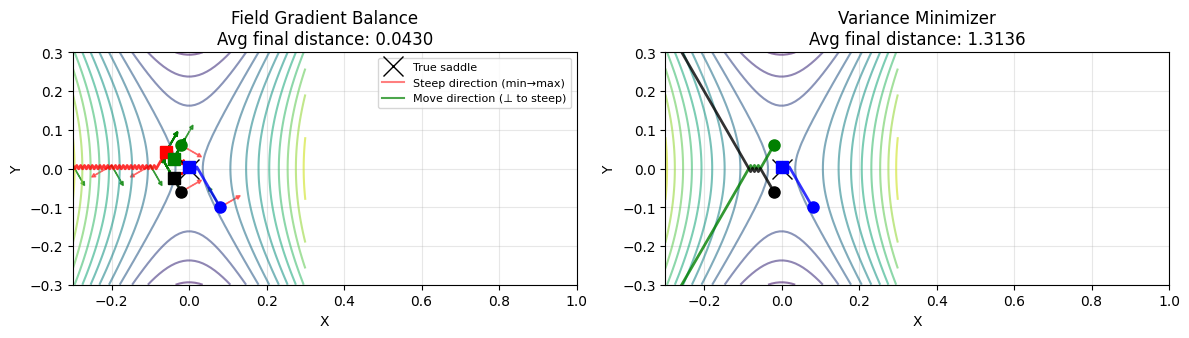


Strategy Performance Summary:
Field Gradient Balance   : 0.0430 avg distance
Variance Minimizer       : 1.3136 avg distance
DETAILED DEMONSTRATION: Field Gradient Balance Strategy

Concept:
- Find steepest direction (lowest robot → highest robot)
- Move PERPENDICULAR to this direction
- This follows the 'stable axis' of the saddle toward center

Analogy: Imagine a horse saddle:
- One axis curves UP like a hill ∩ (unstable)
- Other axis curves DOWN like valley ∪ (stable)
- We move along the stable axis toward the saddle center

Testing strategy: field_gradient_balance
Starting position: [0.0500, 0.0300]
Iter 0: pos=[0.0450, 0.0213], dist_to_saddle=0.0498, z_var=0.0044
     steep_dir=[0.866, -0.500], perp_dir=[0.500, 0.866]
Converged at iteration 9

Result: Started at [0.05, 0.03], ended at [-0.0000, -0.0046]
Final distance to saddle: 0.0046

Detailed test showing movement directions:

Testing strategy: field_gradient_balance
Starting position: [0.0100, -0.0500]
Iter 0: pos=[0.0050, -0.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

class ReactiveSaddleKeeper:
    def __init__(self, robot_distance=0.3, step_size=0.01):
        self.robot_distance = robot_distance
        self.step_size = step_size
        
    def scalar_field(self, x, y):
        """Same bimodal scalar field from notebook"""
        gaussian1 = -((x + 2)**2 + y**2) / 2
        gaussian2 = -((x - 2)**2 + y**2) / 2
        max_exp = np.maximum(gaussian1, gaussian2)
        return max_exp + np.log(np.exp(gaussian1 - max_exp) + np.exp(gaussian2 - max_exp))
    
    def get_robot_positions(self, centroid):
        """Get 3 robots in triangular formation"""
        angles = np.array([0, 2*np.pi/3, 4*np.pi/3])
        robots = []
        for angle in angles:
            x = centroid[0] + self.robot_distance * np.cos(angle)
            y = centroid[1] + self.robot_distance * np.sin(angle)
            robots.append([x, y])
        return np.array(robots)
    
    def strategy_field_gradient_balance(self, robots, z_values):
        """
        STRATEGY 3: Field Gradient Balance
        
        HOW IT WORKS:
        1. Find steepest direction: from lowest robot to highest robot
        2. Move PERPENDICULAR to this steepest direction
        3. Choose the perpendicular direction that moves towards origin
        
        WHY THIS WORKS:
        - At a saddle point, there are two principal directions:
          * Unstable axis: where field curves like a hill (∩)  
          * Stable axis: where field curves like a valley (∪)
        - The steepest direction (min→max) aligns with the unstable axis
        - Moving perpendicular moves along the stable axis toward saddle center
        - It's like sliding down the "valley" direction of the saddle
        """
        z_array = np.array(z_values)
        
        # Find the direction of steepest change (unstable axis direction)
        max_idx = np.argmax(z_array)
        min_idx = np.argmin(z_array)
        
        steep_direction = robots[max_idx] - robots[min_idx]
        steep_direction = steep_direction / np.linalg.norm(steep_direction)
        
        # Move perpendicular to steep direction (along stable axis)
        perp_direction = np.array([-steep_direction[1], steep_direction[0]])
        
        # Choose perpendicular direction that moves towards center
        current_centroid = np.mean(robots, axis=0)
        if np.dot(perp_direction, -current_centroid) < 0:
            perp_direction = -perp_direction
            
        return perp_direction * 0.5  # Smaller steps for stability
         #else:
            #return np.array([0.0, 0.0])
    
    def strategy_variance_minimizer(self, robots, z_values):
        """
        STRATEGY 4: Variance Minimizer (no threshold)
        
        Always move towards robot with median z-value
        This keeps the formation balanced between high/low regions
        """
        z_array = np.array(z_values)
        current_centroid = np.mean(robots, axis=0)
        
        # Find robot closest to median value
        median_z = np.median(z_array)
        median_idx = np.argmin(np.abs(z_array - median_z))
        median_robot = robots[median_idx]
        
        # Always move towards median robot (no threshold)
        direction = median_robot - current_centroid
        return direction
    
    def reactive_step(self, centroid, strategy_name="field_gradient_balance"):
        """One reactive step: sense current robots, decide direction, move"""
        # SENSE: Get current robot positions and measurements
        robots = self.get_robot_positions(centroid)
        z_values = [self.scalar_field(pos[0], pos[1]) for pos in robots]
        
        # THINK: Choose strategy
        if strategy_name == "field_gradient_balance":
            direction = self.strategy_field_gradient_balance(robots, z_values)
        elif strategy_name == "variance_minimizer":
            direction = self.strategy_variance_minimizer(robots, z_values)
        else:
            direction = np.array([0.0, 0.0])
        
        # ACT: Take small step
        #if np.linalg.norm(direction) > 0:
        direction = direction / np.linalg.norm(direction)
        new_centroid = centroid + self.step_size * direction
       # else:
        #    new_centroid = centroid.copy()
        
        # Return diagnostics
        diagnostics = {
            'robots': robots,
            'z_values': z_values,
            'z_min': min(z_values),
            'z_max': max(z_values),
            'z_var': np.var(z_values),
            'direction': direction,
            'steep_direction': None,
            'perp_direction': None
        }
        
        # Add extra diagnostics for field_gradient_balance
        if strategy_name == "field_gradient_balance":
            z_array = np.array(z_values)
            max_idx = np.argmax(z_array)
            min_idx = np.argmin(z_array)
            steep_dir = robots[max_idx] - robots[min_idx]
            if np.linalg.norm(steep_dir) > 0:
                steep_dir = steep_dir / np.linalg.norm(steep_dir)
                perp_dir = np.array([-steep_dir[1], steep_dir[0]])
                diagnostics['steep_direction'] = steep_dir
                diagnostics['perp_direction'] = perp_dir
        
        return new_centroid, diagnostics
    
    def test_reactive_keeping(self, start_pos, strategy_name, max_iterations=500, verbose=True):
        """Test reactive station keeping"""
        centroid = np.array(start_pos, dtype=float)
        trajectory = [centroid.copy()]
        diagnostics_history = []
        
        if verbose:
            print(f"\nTesting strategy: {strategy_name}")
            print(f"Starting position: [{start_pos[0]:.4f}, {start_pos[1]:.4f}]")
        
        for i in range(max_iterations):
            new_centroid, diag = self.reactive_step(centroid, strategy_name)
            
            trajectory.append(new_centroid.copy())
            diagnostics_history.append(diag)
            centroid = new_centroid
            
            # Print progress
            if verbose and i % 100 == 0:
                dist_to_saddle = np.linalg.norm(centroid)
                print(f"Iter {i}: pos=[{centroid[0]:.4f}, {centroid[1]:.4f}], "
                      f"dist_to_saddle={dist_to_saddle:.4f}, "
                      f"z_var={diag['z_var']:.4f}")
                
                # Extra info for field_gradient_balance
                if strategy_name == "field_gradient_balance" and diag['steep_direction'] is not None:
                    steep = diag['steep_direction']
                    perp = diag['perp_direction']
                    print(f"     steep_dir=[{steep[0]:.3f}, {steep[1]:.3f}], "
                          f"perp_dir=[{perp[0]:.3f}, {perp[1]:.3f}]")
            
            # Check if converged (very close to saddle)
            if np.linalg.norm(centroid) < 0.005:
                if verbose:
                    print(f"Converged at iteration {i}")
                break
        
        return np.array(trajectory), diagnostics_history
    
    def compare_strategies(self, start_positions=None):
        """Compare the two working strategies"""
        if start_positions is None:
            start_positions = [[-0.05, -0.03], [0.08, -0.1], [-0.02, 0.06],[-0.02, -0.06]]
        
        strategies = [
            "field_gradient_balance",
            "variance_minimizer"
        ]
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Create field for plotting
        x = np.linspace(-0.3, 0.3, 60)
        y = np.linspace(-0.3, 0.3, 60)
        X, Y = np.meshgrid(x, y)
        Z = self.scalar_field(X, Y)
        
        results = {}
        
        for idx, strategy in enumerate(strategies):
            ax = axes[idx]
            ax.contour(X, Y, Z, levels=15, cmap='viridis', alpha=0.6)
            ax.plot(0, 0, 'kx', markersize=15, linewidth=3, label='True saddle')
            
            colors = ['red', 'blue', 'green', 'black'] 
            strategy_results = []
            
            for i, start_pos in enumerate(start_positions):
                trajectory, diag_hist = self.test_reactive_keeping(
                    start_pos, strategy, 300, verbose=False)
                
                ax.plot(trajectory[:, 0], trajectory[:, 1], 
                       color=colors[i], linewidth=2, alpha=0.8)
                ax.plot(start_pos[0], start_pos[1], 'o', color=colors[i], markersize=8)
                ax.plot(trajectory[-1, 0], trajectory[-1, 1], 's', color=colors[i], markersize=8)
                
                # Show direction vectors for field_gradient_balance
                if strategy == "field_gradient_balance" and len(diag_hist) > 0:
                    for j in range(0, len(diag_hist), 20):  # Show every 20th step
                        diag = diag_hist[j]
                        if diag['steep_direction'] is not None:
                            pos = trajectory[j]
                            steep = diag['steep_direction'] * 0.05  # Scale for visibility
                            perp = diag['perp_direction'] * 0.05
                            
                            # Show steep direction in red
                            ax.arrow(pos[0], pos[1], steep[0], steep[1], 
                                   head_width=0.01, head_length=0.01, 
                                   fc='red', ec='red', alpha=0.5)
                            # Show perpendicular direction in green
                            ax.arrow(pos[0], pos[1], perp[0], perp[1], 
                                   head_width=0.01, head_length=0.01, 
                                   fc='green', ec='green', alpha=0.7)
                
                final_distance = np.linalg.norm(trajectory[-1])
                strategy_results.append(final_distance)
            
            results[strategy] = strategy_results
            avg_distance = np.mean(strategy_results)
            
            title = strategy.replace("_", " ").title()
            ax.set_title(f'{title}\nAvg final distance: {avg_distance:.4f}')
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.grid(True, alpha=0.3)
            ax.set_aspect('equal')
            ax.set_xlim(-0.3, 1)
            ax.set_ylim(-0.3, 0.3)
            
            if strategy == "field_gradient_balance":
                # Add legend for arrows
                ax.plot([], [], 'r-', alpha=0.5, label='Steep direction (min→max)')
                ax.plot([], [], 'g-', alpha=0.7, label='Move direction (⊥ to steep)')
                ax.legend(loc='upper right', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print("\nStrategy Performance Summary:")
        print("=" * 50)
        for strategy, distances in results.items():
            avg_dist = np.mean(distances)
            print(f"{strategy.replace('_', ' ').title():25}: {avg_dist:.4f} avg distance")
        
        return results
    
    def demonstrate_field_gradient_balance(self, start_pos=[0.05, 0.03]):
        """Detailed demonstration of how field_gradient_balance works"""
        print("DETAILED DEMONSTRATION: Field Gradient Balance Strategy")
        print("=" * 60)
        print("\nConcept:")
        print("- Find steepest direction (lowest robot → highest robot)")
        print("- Move PERPENDICULAR to this direction")
        print("- This follows the 'stable axis' of the saddle toward center")
        print("\nAnalogy: Imagine a horse saddle:")
        print("- One axis curves UP like a hill ∩ (unstable)")  
        print("- Other axis curves DOWN like valley ∪ (stable)")
        print("- We move along the stable axis toward the saddle center")
        
        trajectory, diagnostics = self.test_reactive_keeping(start_pos, "field_gradient_balance", 200)
        
        print(f"\nResult: Started at {start_pos}, ended at [{trajectory[-1,0]:.4f}, {trajectory[-1,1]:.4f}]")
        print(f"Final distance to saddle: {np.linalg.norm(trajectory[-1]):.4f}")

# Example usage
if __name__ == "__main__":
    keeper = ReactiveSaddleKeeper(robot_distance=0.25, step_size=0.01)
    
    print("Optimized Reactive Saddle Station-Keeping")
    print("Using only the two strategies that work well near the saddle:")
    print("- Strategy 3: Field Gradient Balance") 
    print("- Strategy 4: Variance Minimizer (no threshold)")
    
    # Test with your updated starting positions
    start_positions = [[-0.8, -0.2], [0.08, -0.1], [-0.02, 0.06],[-0.02, -0.06]]
    results = keeper.compare_strategies(start_positions)
    
    # Detailed demonstration
    keeper.demonstrate_field_gradient_balance()
    
    # Detailed test showing movement vectors
    print("\nDetailed test showing movement directions:")
    trajectory, diagnostics = keeper.test_reactive_keeping([0.01, -0.05], "field_gradient_balance", 5550)